In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("../src/etl")
from db_connection import engine

df=pd.read_sql("SELECT * FROM features", engine) 
print(df.shape)

(447889, 17)


In [6]:
turbines_df = pd.read_sql("SELECT * FROM turbines", engine)
turbines_df

,turbine_id,manufacturer,model
0,WT01,Senvion,MM82
1,WT02,Senvion,MM82
2,WT04,Senvion,MM82
3,WT05,Senvion,MM82
4,WT06,Senvion,MM82
5,WT07,Senvion,MM82
6,WT08,Senvion,MM82
7,WT09,Senvion,MM82
8,WT10,Senvion,MM82


In [7]:
events_df = pd.read_sql(
    "SELECT turbine_id, ts_start, ts_end FROM events WHERE status IN ('Stop', 'Warning', 'Communication')",
    engine,
)  # nly ~2000-3000 rows total, cheap to bring into memory

df=df.sort_values("ts").reset_index(drop=True)
events_df = events_df.sort_values("ts_start").reset_index(drop=True)

df["is_downtime"] = 0  # start assuming normal operation

for turbine_id in df["turbine_id"].unique():
    df_t=df[df["turbine_id"] == turbine_id]
    events_t = events_df[events_df["turbine_id"] == turbine_id]

    if events_t.empty:
        continue

    #for each reading, finds the most recent event that started at or before it
    merged=pd.merge_asof(
        df_t[["ts"]], events_t[["ts_start", "ts_end"]],
        left_on="ts", right_on="ts_start", direction="backward"
    )

    #true only if that event's end also covers this timestamp
    in_downtime=(merged["ts"] <= merged["ts_end"]).fillna(False)

    df.loc[df_t.index[in_downtime.values], "is_downtime"] = 1

df["is_downtime"].value_counts()

is_downtime
0    435128
1     12761
Name: count, dtype: int64

In [8]:
df_train=df[df["is_downtime"] == 0].copy()
df_train=df_train.dropna()

print(df_train.shape)
df_train.isna().sum().sum()  #sanity check, should be 0

(435098, 18)


np.int64(0)

In [9]:
numeric_cols=df_train.select_dtypes(include="number").columns.drop(["is_downtime"])
corr=df_train[numeric_cols].corr()
corr.style.background_gradient(cmap="coolwarm", vmin=-1, vmax=1)

,wind_speed_avg,power_avg,expected_power,power_residual,power_residual_pct,power_avg_moving_6,power_avg_delta,wind_speed_avg_moving_6,wind_speed_avg_delta,gear_oil_temp,gen_bearing_front_temp,gen_bearing_rear_temp,front_bearing_temp,rear_bearing_temp,nacelle_temp
wind_speed_avg,1.000000,0.924641,0.928680,0.144979,0.027122,0.901902,0.090573,0.973832,0.117927,0.443597,-0.229777,0.189877,0.568786,0.555891,-0.467094
power_avg,0.924641,1.000000,0.978827,0.276699,0.053674,0.968440,0.117019,0.906864,0.082581,0.419085,-0.305896,0.153007,0.543431,0.536771,-0.525387
expected_power,0.928680,0.978827,1.000000,0.074145,0.005291,0.950786,0.105047,0.911219,0.083502,0.396890,-0.319674,0.120827,0.525612,0.515796,-0.519150
power_residual,0.144979,0.276699,0.074145,1.000000,0.236666,0.254585,0.076952,0.140339,0.010317,0.178503,0.010446,0.178205,0.180006,0.193640,-0.122432
power_residual_pct,0.027122,0.053674,0.005291,0.236666,1.000000,0.049295,0.014392,0.034168,-0.043705,0.086865,0.028119,0.044674,0.100421,0.092630,-0.061637
power_avg_moving_6,0.901902,0.968440,0.950786,0.254585,0.049295,1.000000,-0.047615,0.926841,-0.034967,0.432702,-0.320772,0.162394,0.556258,0.546473,-0.531912
power_avg_delta,0.090573,0.117019,0.105047,0.076952,0.014392,-0.047615,1.000000,-0.018440,0.701895,0.002308,0.030711,-0.007246,-0.007812,0.002572,0.036551
wind_speed_avg_moving_6,0.973832,0.906864,0.911219,0.140339,0.034168,0.926841,-0.018440,1.000000,-0.032877,0.461528,-0.234387,0.205110,0.585025,0.569319,-0.472815
wind_speed_avg_delta,0.117927,0.082581,0.083502,0.010317,-0.043705,-0.034967,0.701895,-0.032877,1.000000,-0.013461,0.010560,-0.017530,-0.023238,-0.012080,0.024061
gear_oil_temp,0.443597,0.419085,0.396890,0.178503,0.086865,0.432702,0.002308,0.461528,-0.013461,1.000000,0.438637,0.663706,0.930306,0.961272,-0.020849


## What I've done so far and why

- Loaded the `features` view from Azure SQL (447,889 rows) into `df`. This view already joins readings with the reference power curve and computes moving averages / deltas in SQL, since those window functions are cheap to run there.
- Loaded `events` (only Stop/Warning/Communication statuses, the ones that always have a `ts_end`) and used `pd.merge_asof` in pandas to flag each reading as `is_downtime` (1) or not (0). I originally tried this as a correlated subquery in SQL but it was too heavy for the free tier Azure SQL instance and never finished running, so I moved it to pandas instead.
- Built `df_train` by keeping only `is_downtime == 0` rows and dropping the handful of NaN rows (the first reading of each turbine has no previous value for the delta columns). Training only on normal operation is the point of an anomaly detection model: it needs to learn what "normal" looks like so it can later flag what doesn't fit, including the downtime periods themselves.
- Computed a correlation matrix on the numeric columns to check for redundant features before picking what goes into the model.

**Column selection based on the correlation matrix:**
- Power/wind level columns (`power_avg`, `expected_power`, `power_avg_moving_6`, `wind_speed_avg_moving_6`) are all >0.9 correlated with `wind_speed_avg`, so they're basically repeating the same information. Keeping only `wind_speed_avg`.
- `power_residual` and `power_residual_pct` are only weakly correlated with the level columns (this is expected, they represent the deviation from the power curve, which is the whole point).
- `front_bearing_temp` and `rear_bearing_temp` are >0.93 correlated with `gear_oil_temp`, so keeping only `gear_oil_temp`.
- `gen_bearing_front_temp`, `gen_bearing_rear_temp`, and `nacelle_temp` are kept since they are not strongly redundant with anything else.

Final feature set: `wind_speed_avg`, `power_residual`, `power_residual_pct`, `power_avg_delta`, `wind_speed_avg_delta`, `gear_oil_temp`, `gen_bearing_front_temp`, `gen_bearing_rear_temp`, `nacelle_temp`.

In [10]:
feature_cols = [
    "wind_speed_avg",
    "power_residual",
    "power_residual_pct",
    "power_avg_delta",
    "wind_speed_avg_delta",
    "gear_oil_temp",
    "gen_bearing_front_temp",
    "gen_bearing_rear_temp",
    "nacelle_temp",
]

X_train = df_train[feature_cols]
X_train.describe()

,wind_speed_avg,power_residual,power_residual_pct,power_avg_delta,wind_speed_avg_delta,gear_oil_temp,gen_bearing_front_temp,gen_bearing_rear_temp,nacelle_temp
count,435098.000000,435098.000000,435098.000000,435098.000000,435098.000000,435098.000000,435098.000000,435098.000000,435098.000000
mean,7.343555,10.906278,0.013213,0.988108,0.003017,53.392911,38.083181,38.772538,18.726719
std,4.104124,145.827778,0.578165,165.449399,0.883035,7.401215,6.037167,5.313506,5.139137
min,0.142825,-1996.146201,-30.994437,-2068.565186,-11.066226,5.300000,5.368966,4.910345,2.800000
25%,4.378554,-13.304045,-0.093679,-45.801941,-0.451275,52.488335,34.641666,36.681667,15.038473
50%,6.481393,2.724482,0.019952,-0.010327,-0.005055,56.031036,38.936207,39.360001,18.836666
75%,9.472266,48.581908,0.109979,44.729957,0.444691,57.751667,42.185001,41.991379,22.516666
max,25.701880,1826.613032,18.576593,2042.372681,10.633245,59.961666,68.026665,74.093102,36.196667


In [11]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42,
)
model.fit(X_train)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [12]:
import joblib

joblib.dump(model, "../models/isolation_forest.joblib")

['../models/isolation_forest.joblib']

In [13]:
power_curve = pd.read_sql("SELECT * FROM power_curve_reference", engine)
power_curve.to_parquet("../data/processed/power_curve_reference.parquet", index=False)

In [14]:
X_full = df[feature_cols].dropna()

df_scored = df.loc[X_full.index].copy()
df_scored["anomaly"] = model.predict(X_full)
df_scored["anomaly_score"] = model.decision_function(X_full)

df_scored["anomaly"].value_counts()

anomaly
 1    414246
-1     32060
Name: count, dtype: int64

In [15]:
pd.crosstab(df_scored["anomaly"], df_scored["is_downtime"])

is_downtime,0,1
anomaly,,
-1,26187,5873
1,408913,5333


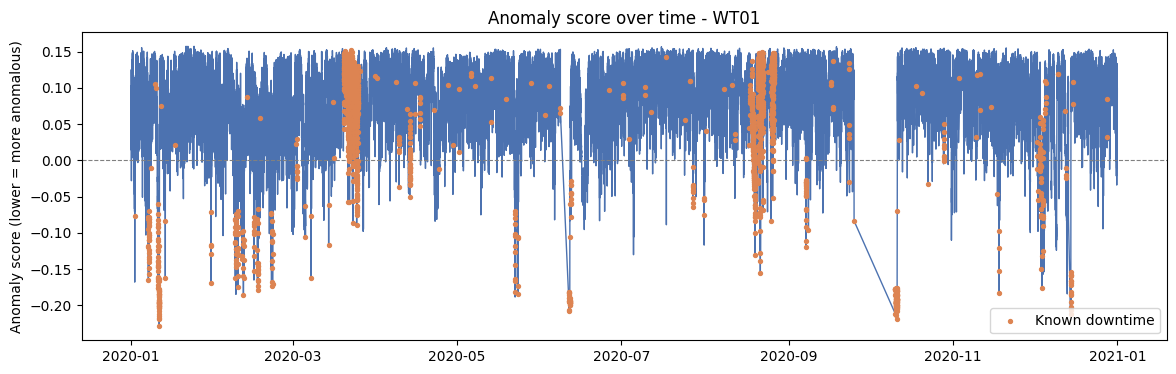

In [16]:
turbine = "WT01"
d = df_scored[df_scored["turbine_id"] == turbine].sort_values("ts")

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(d["ts"], d["anomaly_score"], color="#4C72B0", linewidth=1)

downtime_mask = d["is_downtime"] == 1
ax.scatter(d.loc[downtime_mask, "ts"], d.loc[downtime_mask, "anomaly_score"],
           color="#DD8452", s=8, label="Known downtime", zorder=3)

ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_title(f"Anomaly score over time - {turbine}")
ax.set_ylabel("Anomaly score (lower = more anomalous)")
ax.legend()
plt.show()

In [17]:
#Examination of the plot gap between september and october

d_wt01=df[df["turbine_id"] == "WT01"].sort_values("ts")
gaps=d_wt01["ts"].diff()

gaps[gaps>pd.Timedelta("1h")]

66775     0 days 07:40:00
206304    3 days 06:50:00
234389    0 days 05:10:00
234512    0 days 01:20:00
251974    0 days 06:00:00
263674    0 days 03:30:00
339719    0 days 05:40:00
342111   15 days 07:30:00
343567    0 days 08:00:00
354671    0 days 01:20:00
357470    0 days 07:40:00
409813    0 days 04:10:00
425374    0 days 18:30:00
Name: ts, dtype: timedelta64[us]

**Note on the data gap seen in the WT01 plot**: the diagonal line around September-October 2020 is not a real trend. WT01 has a genuine 15-day data gap starting around that date (checked with `d_wt01["ts"].diff()`), so there simply are no readings there. Matplotlib draws a straight line connecting the last point before the gap to the first point after it, which looks like a gradual drop but is just a plotting artifact of missing data, not something the model detected. A few smaller gaps (hours to a few days) also exist across the dataset but are too short to be visible on a full-year plot.


In [18]:
#Save df_scored

df_scored.to_parquet("../data/processed/df_scored.parquet", index=False)